## Lab15: machine learning
### Sales price prediction using Ames Housing Dataset

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("http://jse.amstat.org/v19n3/decock/AmesHousing.txt",sep='\t')

In [4]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [6]:
df = df[["Overall Qual","Overall Cond","Total Bsmt SF","Gr Liv Area","Central Air","SalePrice"]]

In [7]:
df

,Overall Qual,Overall Cond,Total Bsmt SF,Gr Liv Area,Central Air,SalePrice
0,6,5,1080.0,1656,Y,215000
1,5,6,882.0,896,Y,105000
2,6,6,1329.0,1329,Y,172000
3,7,5,2110.0,2110,Y,244000
4,5,5,928.0,1629,Y,189900
...,...,...,...,...,...,...
2925,6,6,1003.0,1003,Y,142500
2926,5,5,864.0,902,Y,131000
2927,5,5,912.0,970,Y,132000
2928,5,5,1389.0,1389,Y,170000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2930 non-null   int64  
 1   Overall Cond   2930 non-null   int64  
 2   Total Bsmt SF  2929 non-null   float64
 3   Gr Liv Area    2930 non-null   int64  
 4   Central Air    2930 non-null   str    
 5   SalePrice      2930 non-null   int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 137.5 KB


In [9]:
#cleaning
df.dropna(axis=0,inplace = True)
df.isna().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Gr Liv Area      0
Central Air      0
SalePrice        0
dtype: int64

In [10]:
df["Central Air"] = df["Central Air"].map({"Y" : 1,"N": 0})
df.info()

<class 'pandas.DataFrame'>
Index: 2929 entries, 0 to 2929
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2929 non-null   int64  
 1   Overall Cond   2929 non-null   int64  
 2   Total Bsmt SF  2929 non-null   float64
 3   Gr Liv Area    2929 non-null   int64  
 4   Central Air    2929 non-null   int64  
 5   SalePrice      2929 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 160.2 KB


## EDA (Exploratory Data Analysis)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

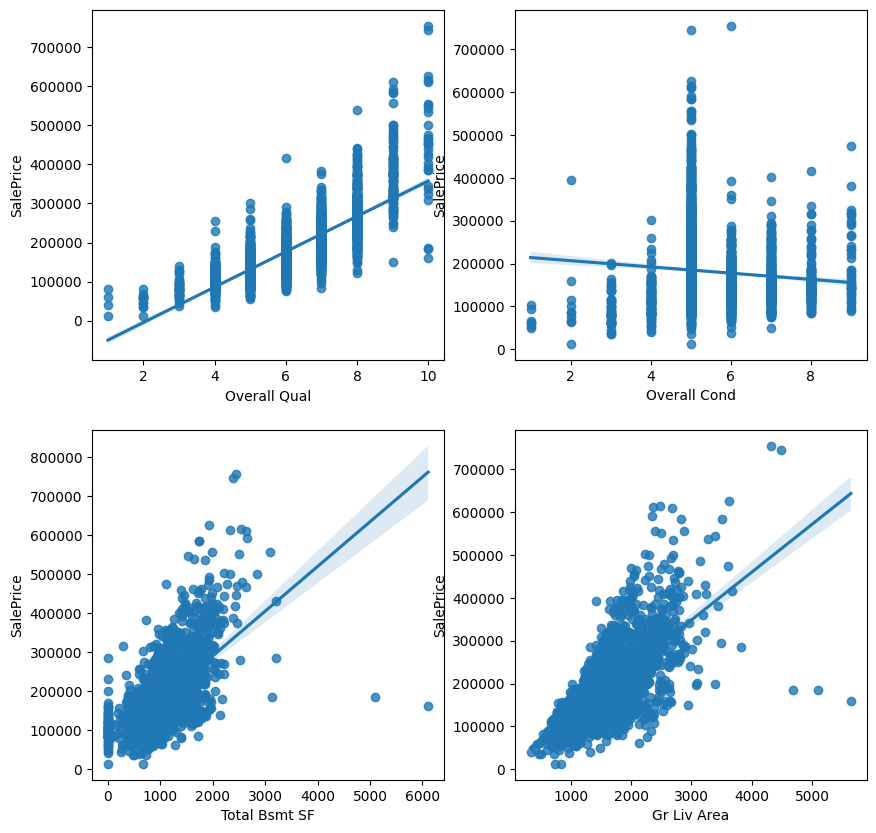

In [12]:
fig, axes = plt.subplots(2,2, figsize=(10,10))
sns.regplot(ax=axes[0,0],data = df,x="Overall Qual",y="SalePrice")
sns.regplot(ax=axes[0,1],data = df,x="Overall Cond",y="SalePrice")
sns.regplot(ax=axes[1,0],data = df,x="Total Bsmt SF",y="SalePrice")
sns.regplot(ax=axes[1,1],data = df,x="Gr Liv Area",y="SalePrice")

<Axes: xlabel='Central Air', ylabel='SalePrice'>

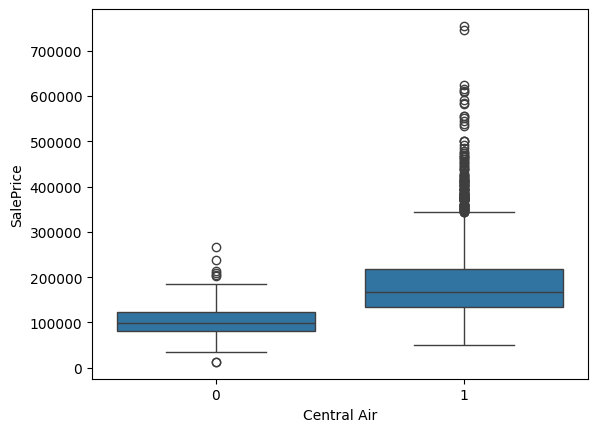

In [13]:
sns.boxplot(data=df,x='Central Air',y='SalePrice')
#중앙에 있는 선이 평균
#파란 박스 밑에선은 25%
#파란 박스 위에선은 75%
#IQR이라고 부른다
#맨밑에 선은 minimum, 맨위에선은 maximum, 범위 벗어나는거는 아웃라이어(통계에서 빼버림)

## Regression with Scikit-learn

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [15]:
# data
# X = df['Gr Liv Area'].values # input features
X = df[['Gr Liv Area','Overall Qual']]
Y = df['SalePrice'].values # targets/ labels

if X.ndim == 1:
    X = X.reshape(-1,1)

Y = Y.reshape(-1,1)
print(X.shape,Y.shape)
print(X)
print(Y)

(2929, 2) (2929, 1)
      Gr Liv Area  Overall Qual
0            1656             6
1             896             5
2            1329             6
3            2110             7
4            1629             5
...           ...           ...
2925         1003             6
2926          902             5
2927          970             5
2928         1389             5
2929         2000             7

[2929 rows x 2 columns]
[[215000]
 [105000]
 [172000]
 ...
 [132000]
 [170000]
 [188000]]


In [16]:
# Standardization
sc_X = StandardScaler()
sc_Y = StandardScaler()
X_std = sc_X.fit_transform(X)
Y_std = sc_Y.fit_transform(Y)

In [17]:
print(X_std)
print(Y_std)

[[ 0.30887979 -0.06777463]
 [-1.19492198 -0.77674566]
 [-0.33815071 -0.06777463]
 ...
 [-1.04849917 -0.77674566]
 [-0.21942951 -0.77674566]
 [ 0.98954796  0.6411964 ]]
[[ 0.42783926]
 [-0.94949293]
 [-0.11057241]
 ...
 [-0.61142048]
 [-0.13561481]
 [ 0.08976682]]


Learning the parameters of a prediction function and testing it on the same data is a methodological mistake: a model that would just repeat the labels of the samples that it has just seen would have a perfect score but would fail to predict anything useful on yet-unseen data. This situation is called overfitting. To avoid it, it is common practice when performing a (supervised) machine learning experiment to hold out part of the available data as a test set X_test, y_test. Note that the word “experiment” is not intended to denote academic use only, because even in commercial settings machine learning usually starts out experimentally. Here is a flowchart of typical cross validation workflow in model training. The best parameters can be determined by grid search techniques.

In [18]:
#split data to train/test
X_train, X_test , Y_train, Y_test = train_test_split(X_std,Y_std,test_size=0.3)

In [19]:
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(2050, 2) (2050, 1)
(879, 2) (879, 1)


In [20]:
# Model selction
from sklearn import svm
from my_linear_model import MySimpleLinearRegression

# model = LinearRegression()
model = MySimpleLinearRegression()
# model = svm.SVR(degree=5) #non-linear

In [21]:
# Model fitting / training
model.fit(X_train,Y_train)

In [22]:
if hasattr(model,"coef_"):
    print(model.coef_, model.intercept_)

0.7081200970725663 0.0003818371690956293


In [23]:
Y_pred = model.predict(X_test)

In [24]:
# evaluation
# for y,y_pred in zip(Y_test,Y_pred):
#     print(y,y_pred)
from sklearn.metrics import r2_score

score = r2_score(Y_test, Y_pred)
print(f"R2: {score}")

R2: 0.49091791232906823


[Text(0.5, 0, 'y_test'), Text(0, 0.5, 'y_pred')]

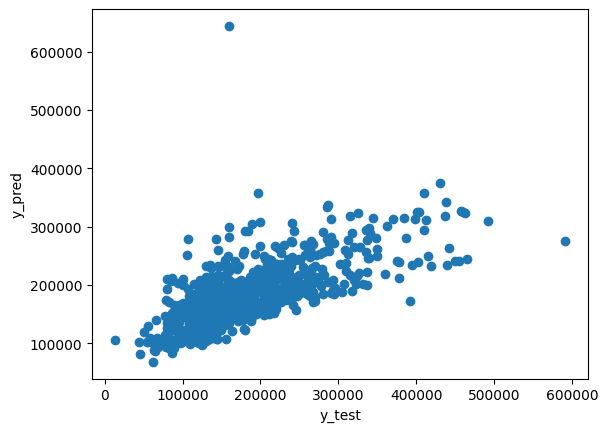

In [25]:
#plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(sc_Y.inverse_transform(Y_test),sc_Y.inverse_transform(Y_pred.reshape(-1,1)))
ax.set(xlabel='y_test',ylabel='y_pred')